LIBRARIES

In [5]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [6]:
IMG_HEIGHT= 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels='inferred',
    label_mode ='int',
    image_size =(IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels='inferred',
    label_mode ='int',
    image_size =(IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

normalize = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top = False,
    weights = 'imagenet'
)

model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics =['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

TRAINING

In [9]:
EPOCHS =10
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs =EPOCHS
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 165s 793ms/step - accuracy: 0.7233 - loss: 0.9644 - val_accuracy: 0.4920 - val_loss: 6.2140
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 151s 803ms/step - accuracy: 0.8523 - loss: 0.4484 - val_accuracy: 0.3150 - val_loss: 9.2621
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 150s 796ms/step - accuracy: 0.8637 - loss: 0.4050 - val_accuracy: 0.4910 - val_loss: 5.9705
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 150s 798ms/step - accuracy: 0.8930 - loss: 0.3232 - val_accuracy: 0.5620 - val_loss: 3.6850
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 148s 786ms/step - accuracy: 0.9137 - loss: 0.2602 - val_accuracy: 0.2930 - val_loss: 8.5473
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 159s 843ms/step - accuracy: 0.8760 - loss: 0.3983 - val_accuracy: 0.2450 - val_loss: 11.4217
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 166s 880ms/step - accuracy: 0.9133 - loss: 0.2547 - val_accuracy: 0.5870 - val_loss: 3.3188
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9293 - l

PLOTTING

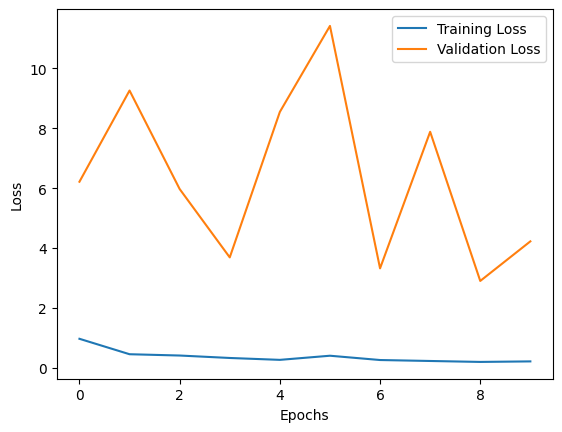

In [10]:
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

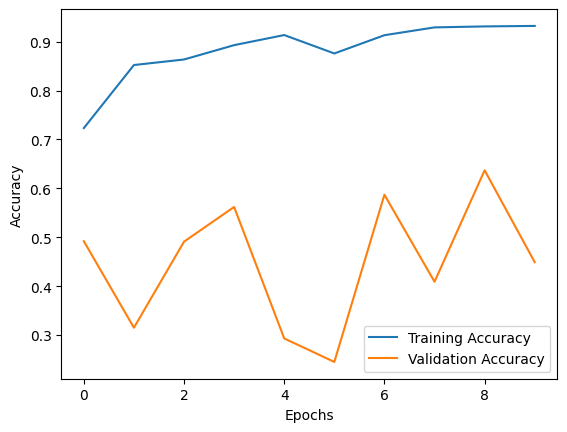

In [11]:
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()